## Conectarse a RDS PostgreSQL

In [1]:
import boto3
import json
from sqlalchemy import create_engine

# Recuperar credenciales desde Secrets Manager
client = boto3.client("secretsmanager", region_name="us-east-1")
secret = client.get_secret_value(SecretId="itam/rds/flights/credentials")
creds = json.loads(secret["SecretString"])

# Endpoint primario — para crear tablas e insertar datos
RDS_ENDPOINT = "itam-northwind-561137843164.cw5yuskyg5vm.us-east-1.rds.amazonaws.com"

engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{RDS_ENDPOINT}:{creds['port']}/{creds['dbname']}"
)

with engine.connect() as conn:
    print("✓ Conexión exitosa a RDS PostgreSQL")

✓ Conexión exitosa a RDS PostgreSQL


## Definir el schema y crear las tres tablas

In [2]:
from sqlalchemy.orm import DeclarativeBase, mapped_column, Mapped
from sqlalchemy import String, Integer, Float, ForeignKey
from typing import Optional

class Base(DeclarativeBase):
    pass

class Airline(Base):
    __tablename__ = "airlines"
    iata_code:  Mapped[str]             = mapped_column(String(10),  primary_key=True)
    airline:    Mapped[str]             = mapped_column(String(100))

class Airport(Base):
    __tablename__ = "airports"
    iata_code:  Mapped[str]             = mapped_column(String(10),  primary_key=True)
    airport:    Mapped[str]             = mapped_column(String(200))
    city:       Mapped[Optional[str]]   = mapped_column(String(100))
    state:      Mapped[Optional[str]]   = mapped_column(String(50))
    country:    Mapped[Optional[str]]   = mapped_column(String(50))
    latitude:   Mapped[Optional[float]] = mapped_column(Float)
    longitude:  Mapped[Optional[float]] = mapped_column(Float)

class Flight(Base):
    __tablename__ = "flights"
    id:                  Mapped[int]             = mapped_column(Integer, primary_key=True, autoincrement=True)
    year:                Mapped[int]             = mapped_column(Integer)
    month:               Mapped[int]             = mapped_column(Integer)
    day:                 Mapped[int]             = mapped_column(Integer)
    airline:             Mapped[str]             = mapped_column(String(10), ForeignKey("airlines.iata_code"))
    origin_airport:      Mapped[str]             = mapped_column(String(10), ForeignKey("airports.iata_code"))
    destination_airport: Mapped[str]             = mapped_column(String(10), ForeignKey("airports.iata_code"))
    departure_delay:     Mapped[Optional[float]] = mapped_column(Float)
    arrival_delay:       Mapped[Optional[float]] = mapped_column(Float)
    cancelled:           Mapped[int]             = mapped_column(Integer)
    cancellation_reason: Mapped[Optional[str]]   = mapped_column(String(5))
    distance:            Mapped[Optional[float]] = mapped_column(Float)
    air_system_delay:    Mapped[Optional[float]] = mapped_column(Float)
    airline_delay:       Mapped[Optional[float]] = mapped_column(Float)
    weather_delay:       Mapped[Optional[float]] = mapped_column(Float)
    late_aircraft_delay: Mapped[Optional[float]] = mapped_column(Float)
    security_delay:      Mapped[Optional[float]] = mapped_column(Float)

# Idempotencia
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)
print("✓ Schema creado en PostgreSQL")

✓ Schema creado en PostgreSQL


## Insertar datos

In [5]:
import pandas as pd
from sqlalchemy.orm import Session
from sqlalchemy import insert


def load_csv(session, model, df):
    df = df.rename(columns=str.lower)
    records = [
        {k: None if pd.isnull(v) else v for k, v in row.items()}
        for row in df.to_dict(orient="records")
    ]
    session.execute(insert(model), records)
    print(f"✓ {model.__tablename__}: {len(records):,} filas cargadas")

df_airlines = pd.read_csv("data/flights/airlines.csv")
df_airports = pd.read_csv("data/flights/airports.csv")
df_flights  = pd.read_csv("data/flights/flights.csv", nrows=500_000)

with Session(engine) as session:
    load_csv(session, Airline, df_airlines)
    load_csv(session, Airport, df_airports)
    load_csv(session, Flight,  df_flights)
    session.commit()
    print("✓ Carga completa")

✓ airlines: 14 filas cargadas
✓ airports: 322 filas cargadas
✓ flights: 500,000 filas cargadas
✓ Carga completa


## Consultas con awswrangler

### Conectarse a la réplica

In [6]:
# Read Replica — para queries analíticas
REPLICA_ENDPOINT = "itam-northwind-replica-561137843164.cw5yuskyg5vm.us-east-1.rds.amazonaws.com"

engine_replica = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{REPLICA_ENDPOINT}:{creds['port']}/{creds['dbname']}"
)

with engine_replica.connect() as conn:
    print("✓ Conexión exitosa a Read Replica")

✓ Conexión exitosa a Read Replica


### Repetir las 8 preguntas con queries SQL

,origin_airport,destination_airport,total_vuelos
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


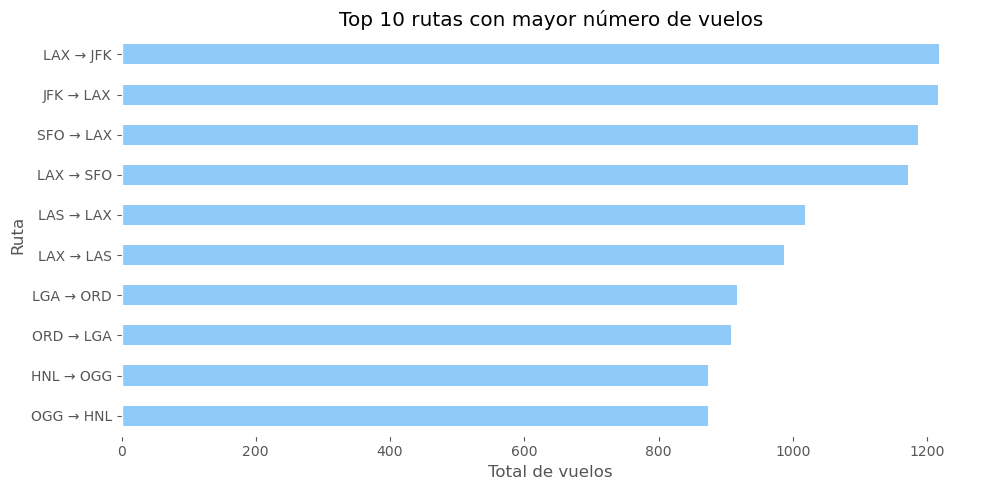

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# P1 — Top 10 rutas con mayor número de vuelos
query_p1 = """
SELECT 
    origin_airport,
    destination_airport,
    COUNT(*) AS total_vuelos
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_vuelos DESC
LIMIT 10;
"""

df_p1 = pd.read_sql(query_p1, engine_replica)
display(df_p1)

# Visualización
df_p1["ruta"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_p1.plot(kind="barh", x="ruta", y="total_vuelos", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 10 rutas con mayor número de vuelos")
ax.set_xlabel("Total de vuelos")
ax.set_ylabel("Ruta")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,total_vuelos,total_cancelados,pct_cancelados
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


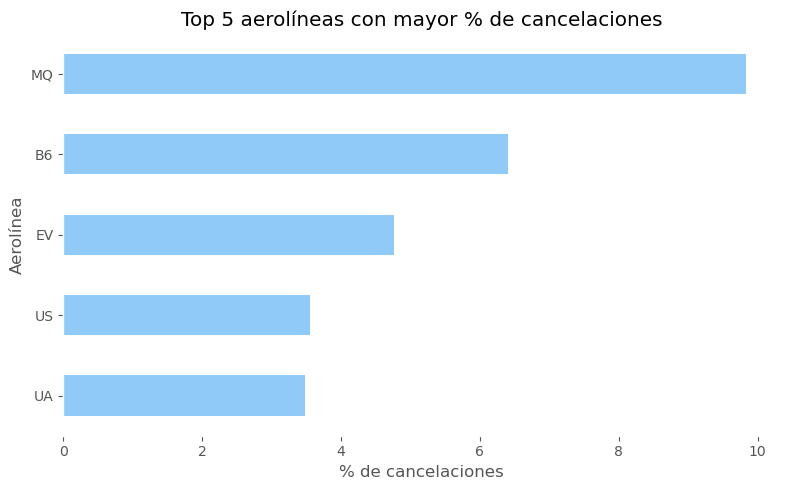

In [13]:
# P2 — Top 5 aerolíneas con mayor porcentaje de vuelos cancelados
query_p2 = """
SELECT 
    airline,
    COUNT(*) AS total_vuelos,
    SUM(cancelled) AS total_cancelados,
    ROUND(SUM(cancelled)::numeric / COUNT(*) * 100, 2) AS pct_cancelados
FROM flights
GROUP BY airline
ORDER BY pct_cancelados DESC
LIMIT 5;
"""

df_p2 = pd.read_sql(query_p2, engine_replica)
display(df_p2)

# Visualización
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")
df_p2.plot(kind="barh", x="airline", y="pct_cancelados", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 5 aerolíneas con mayor % de cancelaciones")
ax.set_xlabel("% de cancelaciones")
ax.set_ylabel("Aerolínea")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,cancellation_reason,total_cancelados
0,A,3230
1,B,10630
2,C,2962
3,D,2


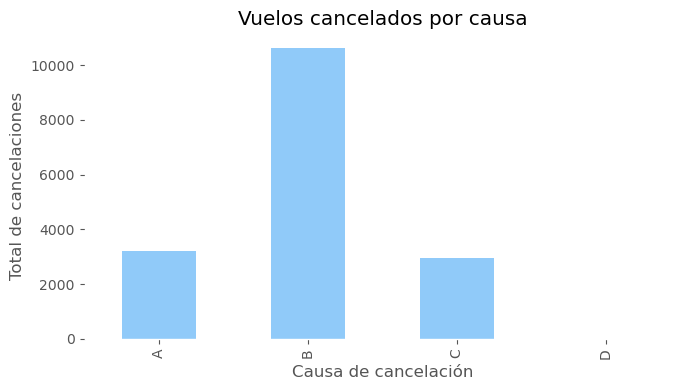

In [15]:
# P3 — Vuelos cancelados por causa
query_p3 = """
SELECT 
    cancellation_reason,
    COUNT(*) AS total_cancelados
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason;
"""

df_p3 = pd.read_sql(query_p3, engine_replica)
display(df_p3)

# Visualización
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
df_p3.plot(kind="bar", x="cancellation_reason", y="total_cancelados", legend=False, color="#90caf9", ax=ax)
ax.set_title("Vuelos cancelados por causa")
ax.set_xlabel("Causa de cancelación")
ax.set_ylabel("Total de cancelaciones")
plt.tight_layout()
plt.show()

,month,promedio_retraso
0,1,32.571225
1,2,42.306487


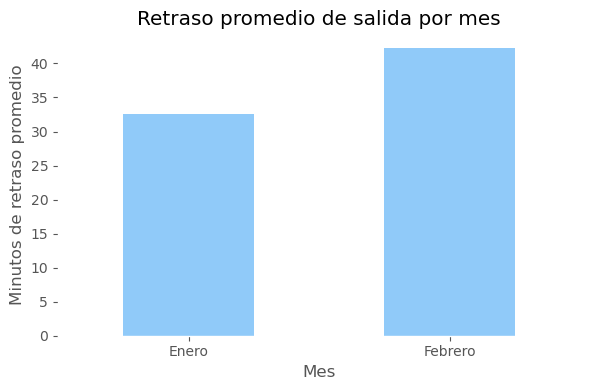

In [17]:
# P4 — Retraso promedio de salida por mes
query_p4 = """
SELECT 
    month,
    AVG(departure_delay) AS promedio_retraso
FROM flights
WHERE cancelled = 0 AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

df_p4 = pd.read_sql(query_p4, engine_replica)
display(df_p4)

# Visualización
meses = {1: "Enero", 2: "Febrero"}
df_p4["mes_nombre"] = df_p4["month"].map(meses)

fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
ax.set_facecolor("white")
df_p4.plot(kind="bar", x="mes_nombre", y="promedio_retraso", legend=False, color="#90caf9", ax=ax)
ax.set_title("Retraso promedio de salida por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Minutos de retraso promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,origin_airport,total_minutos_clima
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


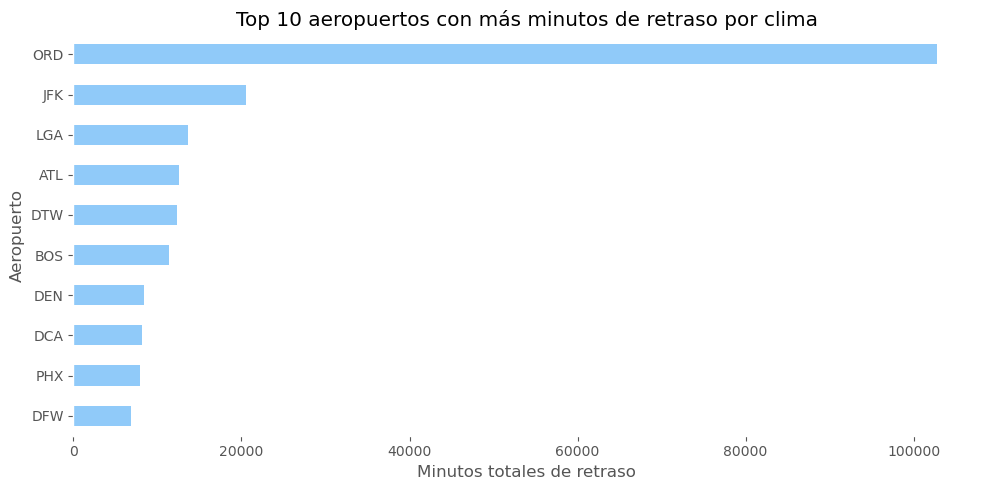

In [18]:
# P5 — Top 10 aeropuertos con más minutos de retraso por clima
query_p5 = """
SELECT 
    origin_airport,
    SUM(weather_delay) AS total_minutos_clima
FROM flights
WHERE weather_delay > 0
GROUP BY origin_airport
ORDER BY total_minutos_clima DESC
LIMIT 10;
"""

df_p5 = pd.read_sql(query_p5, engine_replica)
display(df_p5)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_p5.plot(kind="barh", x="origin_airport", y="total_minutos_clima", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 10 aeropuertos con más minutos de retraso por clima")
ax.set_xlabel("Minutos totales de retraso")
ax.set_ylabel("Aeropuerto")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,origin_airport,destination_airport,arrival_delay,rank
0,AA,BHM,DFW,1971.0,1
1,AS,LAX,SEA,451.0,1
2,B6,MSY,JFK,502.0,1
3,DL,MIA,MSP,1174.0,1
4,EV,SHV,DFW,723.0,1
5,F9,ORD,MIA,686.0,1
6,HA,JFK,HNL,1013.0,1
7,MQ,CLL,DFW,788.0,1
8,NK,TPA,ORD,570.0,1
9,OO,CHO,ORD,953.0,1


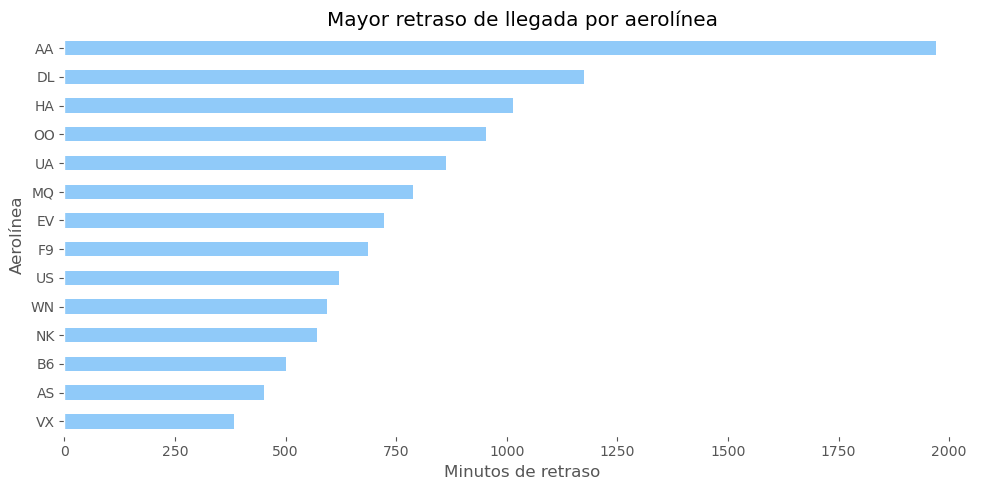

In [20]:
# W1 — Vuelo con mayor retraso de llegada por aerolínea
query_w1 = """
SELECT *
FROM (
    SELECT 
        airline,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC NULLS LAST) AS rank
    FROM flights
    WHERE cancelled = 0
) ranked
WHERE rank = 1;
"""

df_w1 = pd.read_sql(query_w1, engine_replica)
display(df_w1)

# Visualización
df_w1_sorted = df_w1.sort_values("arrival_delay", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_w1_sorted.plot(kind="barh", x="airline", y="arrival_delay", legend=False, color="#90caf9", ax=ax)
ax.set_title("Mayor retraso de llegada por aerolínea")
ax.set_xlabel("Minutos de retraso")
ax.set_ylabel("Aerolínea")
plt.tight_layout()
plt.show()

,month,total_vuelos,vuelos_mes_anterior,variacion,variacion_pct
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.50
3,4,485151,504312,-19161,-3.80
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


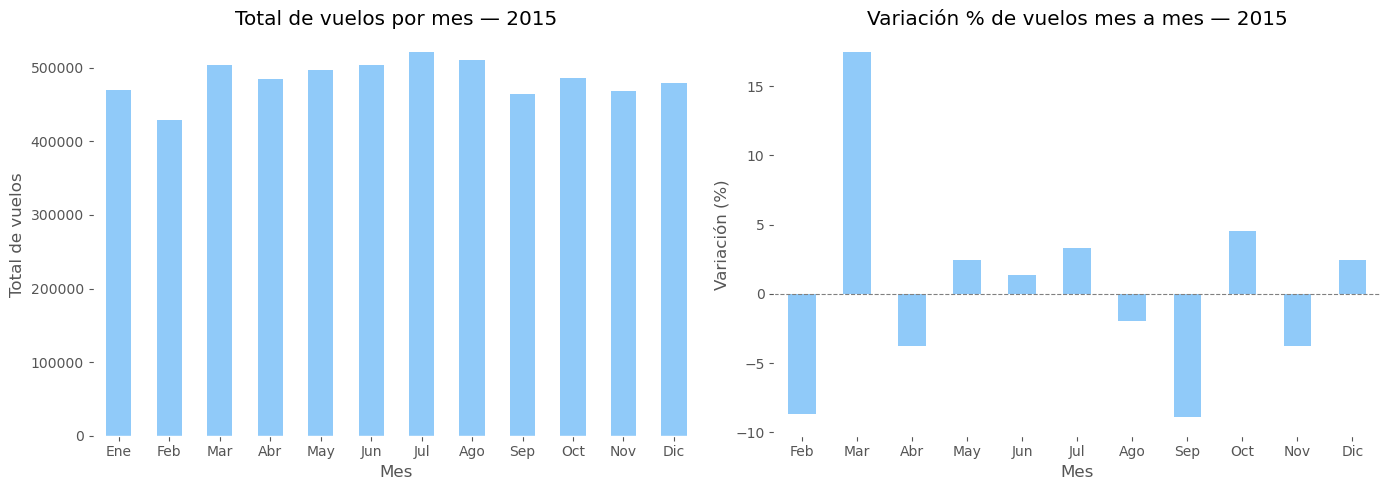

In [23]:
import awswrangler as wr

# W2 — Variación mes a mes en el total de vuelos (desde Silver en Athena)
query_w2 = """
SELECT
    month,
    SUM(total_flights) AS total_vuelos,
    LAG(SUM(total_flights)) OVER (ORDER BY month) AS vuelos_mes_anterior,
    SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month) AS variacion,
    ROUND(
        100.0 * (SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month))
        / NULLIF(LAG(SUM(total_flights)) OVER (ORDER BY month), 0), 2
    ) AS variacion_pct
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month
"""

df_w2 = wr.athena.read_sql_query(query_w2, database="flights_silver", ctas_approach=False)
display(df_w2)

# Visualización
meses = {1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
         7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"}
df_w2["mes_nombre"] = df_w2["month"].map(meses)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Gráfica 1 — Total de vuelos
axes[0].set_facecolor("white")
df_w2.plot(kind="bar", x="mes_nombre", y="total_vuelos", legend=False, color="#90caf9", ax=axes[0])
axes[0].set_title("Total de vuelos por mes — 2015")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Total de vuelos")
axes[0].tick_params(axis="x", rotation=0)

# Gráfica 2 — Cambio porcentual
axes[1].set_facecolor("white")
df_w2.dropna(subset=["variacion_pct"]).plot(
    kind="bar", x="mes_nombre", y="variacion_pct", legend=False, color="#90caf9", ax=axes[1]
)
axes[1].set_title("Variación % de vuelos mes a mes — 2015")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Variación (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

,row_num,id,airline,destination_airport,departure_delay
0,1,3202,OO,SEA,-13.0
1,2,13269,OO,MRY,-13.0
2,3,13861,UA,BOS,-11.0
3,4,12184,OO,OAK,-11.0
4,5,1741,OO,TUS,-10.0


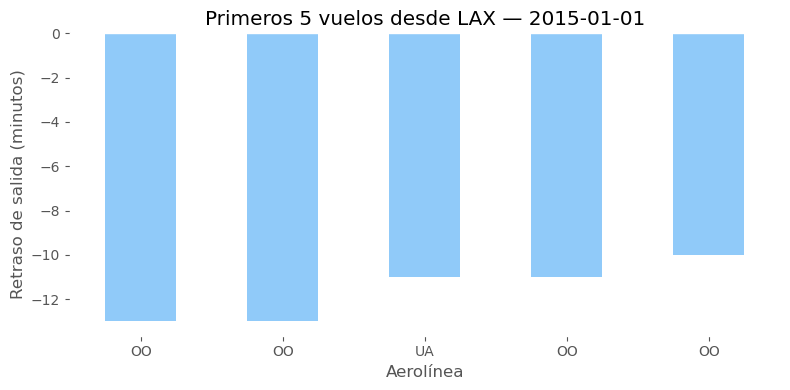

In [24]:
# W3 — Primeros 5 vuelos desde LAX el 2015-01-01
query_w3 = """
SELECT 
    ROW_NUMBER() OVER (
        PARTITION BY year, month, day, origin_airport 
        ORDER BY departure_delay ASC NULLS LAST
    ) AS row_num,
    id,
    airline,
    destination_airport,
    departure_delay
FROM flights
WHERE year = 2015 
  AND month = 1 
  AND day = 1 
  AND origin_airport = 'LAX'
LIMIT 5;
"""

df_w3 = pd.read_sql(query_w3, engine_replica)
display(df_w3)

# Visualización
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
ax.set_facecolor("white")
df_w3.plot(kind="bar", x="airline", y="departure_delay", legend=False, color="#90caf9", ax=ax)
ax.set_title("Primeros 5 vuelos desde LAX — 2015-01-01")
ax.set_xlabel("Aerolínea")
ax.set_ylabel("Retraso de salida (minutos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()